# Model 1 — robust temperature-only baseline

Final baseline model:

$$
y_i=\log(PR_i)
$$

$$
y_i \sim StudentT(\nu,\mu_i,\sigma)
$$

$$
\mu_i=\alpha+\beta_T x_{T,i}
$$

where:

$$
x_T=\frac{T_m-T_{min}}{T_{max}-T_{min}}
$$

$T_{min}$ and $T_{max}$ are computed from the filtered modelling dataset, so $x_T$ is always in the range $[0,1]$. With this normalization, $\alpha$ is the expected $\log(PR)$ at the minimum observed module temperature, while $\beta_T$ is the change in $\log(PR)$ between the minimum and maximum observed module temperature.

The model uses a Student-t likelihood to make inference robust to remaining outliers. It captures the temperature relationship only and does not include wind or day-level effects.

In [1]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel

RANDOM_SEED = 42
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## 1. Load moderate dataset

In [ ]:
DATA_PATH = "Bayesian-Data-Analytics-PV-Project/onemin-Ground-2016/2016/ground_model_data_irr50_all.csv"
df = pd.read_csv(DATA_PATH)

print("Using clean data:", DATA_PATH)

STAN_MODEL_PATH = Path("Bayesian-Data-Analytics-PV-Project/model_1_temperature_studentt.stan")
STAN_PRIOR_PATH = Path("Bayesian-Data-Analytics-PV-Project/model_1_temperature_studentt_prior_predictive.stan")

print("Using data:", DATA_PATH)
print("Raw shape:", df.shape)
print(df.columns.tolist())

required = ["logPR", "PR", "T_module_C"]
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=required).copy()

temp_min = df["T_module_C"].min()
temp_max = df["T_module_C"].max()
temp_range = temp_max - temp_min
df["x_T"] = (df["T_module_C"] - temp_min) / temp_range

if "day_id" in df.columns:
    df["day_id"] = pd.factorize(df["day_id"])[0] + 1

print("Model shape:", df.shape)
print(f"Temperature range: {temp_min:.2f} ... {temp_max:.2f} degC")
df[["logPR", "PR", "x_T", "T_module_C"]].head()

FileNotFoundError: [Errno 2] No such file or directory: 'Bayesian-Data-Analytics-PV-Project/onemin-Ground-2016/2016/ground_model_data_irr50.csv'

## 2. Prepare Stan data

In [ ]:
y = df["logPR"].to_numpy()
x_T = df["x_T"].to_numpy()
N = len(df)

stan_data = {"N": N, "y": y, "x_T": x_T, "temp_range": temp_range}
prior_data = {"N": N, "x_T": x_T, "temp_range": temp_range}

print("N =", N)
print("x_T range:", x_T.min(), x_T.max())
print("Temperature range [degC]:", temp_range)
print("PR range:", df["PR"].min(), df["PR"].max())

N = 6952
x_T range: 0.0 1.0
Temperature range [degC]: 53.470000000000006
PR range: 0.160382331586119 2.493268175925


## 3. EDA

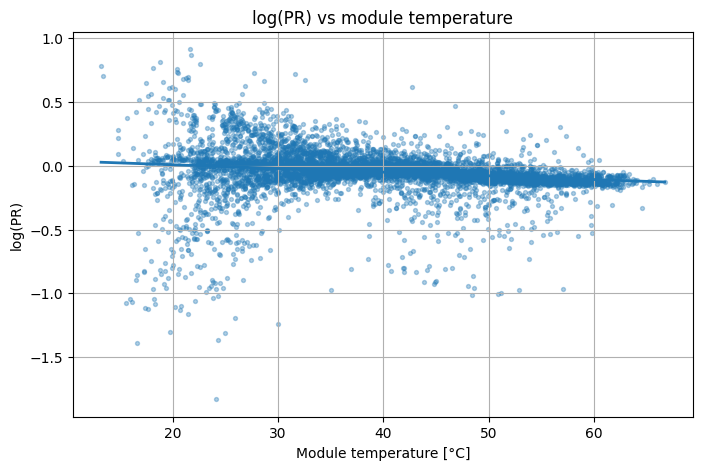

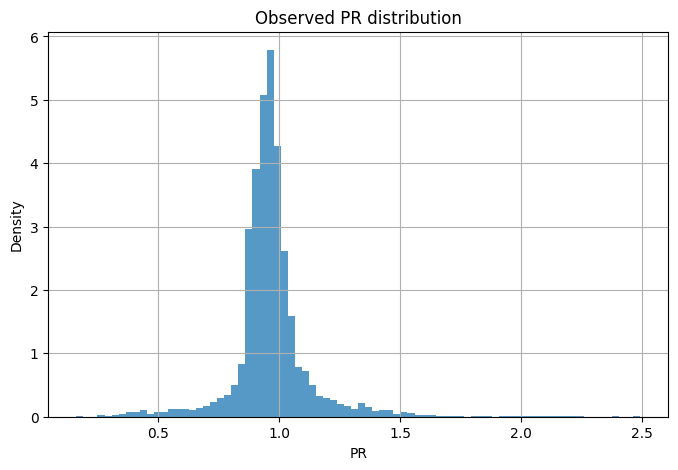

In [ ]:
plt.figure()
plt.scatter(df["T_module_C"], df["logPR"], s=8, alpha=0.35)
p = np.polyfit(df["T_module_C"], df["logPR"], 1)
xx = np.linspace(df["T_module_C"].min(), df["T_module_C"].max(), 200)
plt.plot(xx, np.polyval(p, xx), linewidth=2)
plt.xlabel("Module temperature [°C]")
plt.ylabel("log(PR)")
plt.title("log(PR) vs module temperature")
plt.show()

plt.figure()
plt.hist(df["PR"], bins=80, density=True, alpha=0.75)
plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Observed PR distribution")
plt.show()

## 4. Prior predictive check

Prior predictive checks assess whether the assumed priors generate plausible PR values before conditioning on the data. The summaries include $\beta_T$ on the normalized temperature scale and the corresponding $+10^\circ C$ effect for physical interpretation.

In [ ]:

prior_model = CmdStanModel(stan_file=str(STAN_PRIOR_PATH))
prior_fit = prior_model.sample(
    data=prior_data,
    chains=4,
    iter_warmup=500,
    iter_sampling=500,
    seed=RANDOM_SEED,
)

alpha_prior = prior_fit.stan_variable("alpha")
beta_T_prior = prior_fit.stan_variable("beta_T")
beta_T_per_10C_prior = prior_fit.stan_variable("beta_T_per_10C")
sigma_prior = prior_fit.stan_variable("sigma")
nu_prior = prior_fit.stan_variable("nu")
PR_prior = prior_fit.stan_variable("PR_prior")

print("Prior alpha:", np.percentile(alpha_prior, [5, 50, 95]))
print("Prior beta_T (0 to 1 temperature scale):", np.percentile(beta_T_prior, [5, 50, 95]))
print("Prior beta_T per +10 degC:", np.percentile(beta_T_per_10C_prior, [5, 50, 95]))
print("Prior sigma:", np.percentile(sigma_prior, [5, 50, 95]))
print("Prior nu:", np.percentile(nu_prior, [5, 50, 95]))
print("Prior predictive PR:", np.percentile(PR_prior.flatten(), [1, 5, 50, 95, 99]))

22:30:17 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

22:30:22 - cmdstanpy - INFO - CmdStan done processing.



Prior alpha: [-0.77229545 -0.286515    0.2090281 ]
Prior beta_T (0 to 1 temperature scale): [-4.3841255   0.02396945  4.471189  ]
Prior beta_T per +10 degC: [-0.8199229   0.00448278  0.8362042 ]
Prior sigma: [0.00373733 0.03409575 0.09669261]
Prior nu: [ 6.8588  17.00555 32.15191]
Prior predictive PR: [1.4786999e-02 6.6458700e-02 7.4594500e-01 8.2782300e+00 3.3990104e+01]


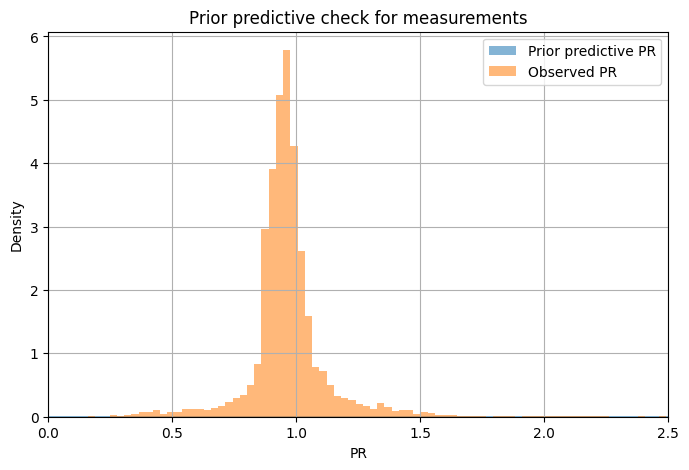

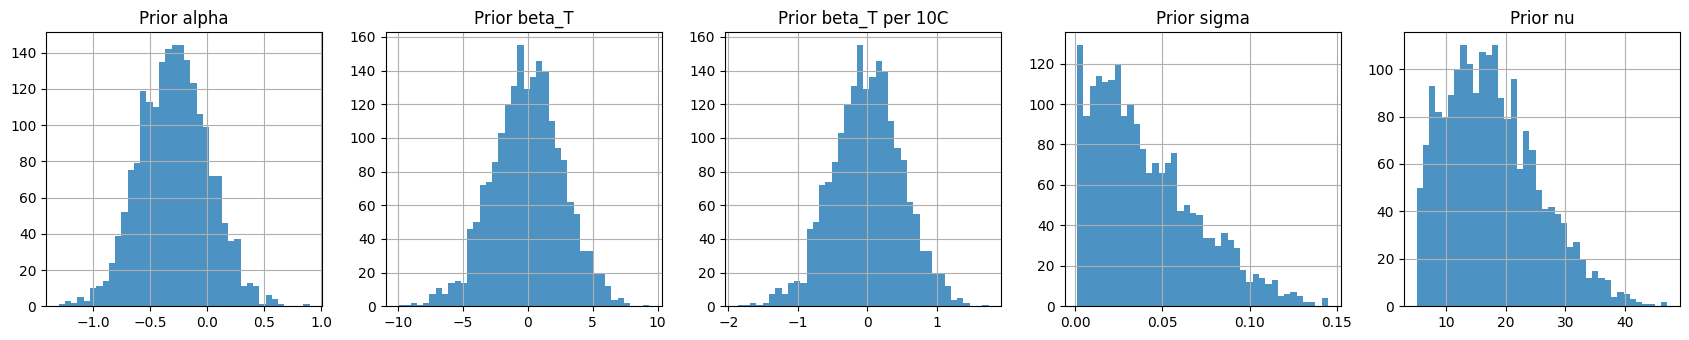

In [ ]:
plt.figure()
plt.hist(PR_prior.flatten(), bins=100, density=True, alpha=0.55, label="Prior predictive PR")
plt.hist(df["PR"], bins=80, density=True, alpha=0.55, label="Observed PR")
plt.xlim(0, 2.5)
plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Prior predictive check for measurements")
plt.xlim([0, 2.5])
plt.legend()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(17, 3.5))
for ax, (name, samples) in zip(
    axes,
    [
        ("alpha", alpha_prior),
        ("beta_T", beta_T_prior),
        ("beta_T per 10C", beta_T_per_10C_prior),
        ("sigma", sigma_prior),
        ("nu", nu_prior),
    ]
):
    ax.hist(samples, bins=40, alpha=0.8)
    ax.set_title(f"Prior {name}")
    ax.grid(True)
plt.tight_layout()
plt.show()

## 5. Fit Model 1

In [ ]:

model = CmdStanModel(stan_file=str(STAN_MODEL_PATH))
fit = model.sample(
    data=stan_data,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=RANDOM_SEED,
    adapt_delta=0.95,
    max_treedepth=12,
)

22:30:34 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

22:31:15 - cmdstanpy - INFO - CmdStan done processing.


## 6. Diagnostics

In [ ]:
print(fit.diagnose())
summary = fit.summary()
display(summary.loc[["alpha", "beta_T", "beta_T_per_10C", "sigma", "nu"]])

draws_pd = fit.draws_pd()
div_cols = [c for c in draws_pd.columns if c.endswith("__") and "divergent" in c]
n_div = int(draws_pd[div_cols[0]].sum()) if div_cols else 0
print("Number of divergences:", n_div)

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
alpha,0.066688,0.000068,0.003423,0.003392,0.061004,0.066737,0.072258,2566.22,2210.060,1.00023
beta_T,-0.207311,0.000118,0.006013,0.005959,-0.217045,-0.207416,-0.197078,2636.31,2543.890,1.00048
beta_T_per_10C,-0.038771,0.000022,0.001125,0.001114,-0.040592,-0.038791,-0.036858,2636.32,2543.890,1.00048
sigma,0.082451,0.000024,0.001042,0.001022,0.080767,0.082428,0.084227,1846.01,1887.180,1.00219
nu,5.004210,0.000085,0.004189,0.003024,5.000180,5.002870,5.012570,1325.64,881.859,1.00110


Number of divergences: 0


## 7. Posterior analysis

In [ ]:
alpha = fit.stan_variable("alpha")
beta_T = fit.stan_variable("beta_T")
beta_T_per_10C = fit.stan_variable("beta_T_per_10C")
sigma = fit.stan_variable("sigma")
nu = fit.stan_variable("nu")
mu = fit.stan_variable("mu")

effect_full_range_pct = 100 * (np.exp(beta_T) - 1)
effect_10C_pct = 100 * (np.exp(beta_T_per_10C) - 1)
effect_1C_pct = 100 * (np.exp(beta_T_per_10C / 10) - 1)

print(f"P(beta_T < 0 | data) = {np.mean(beta_T < 0):.4f}")
print("beta_T percentiles (0 to 1 temperature scale):", np.percentile(beta_T, [5, 50, 95]))
print("beta_T per +10 degC percentiles:", np.percentile(beta_T_per_10C, [5, 50, 95]))
print("Effect across observed temperature range [%]:", np.percentile(effect_full_range_pct, [5, 50, 95]))
print("Effect per +10°C [%]:", np.percentile(effect_10C_pct, [5, 50, 95]))
print("Effect per +1°C [%]:", np.percentile(effect_1C_pct, [5, 50, 95]))
print("sigma percentiles:", np.percentile(sigma, [5, 50, 95]))
print("nu percentiles:", np.percentile(nu, [5, 50, 95]))

P(beta_T < 0 | data) = 1.0000
beta_T percentiles (0 to 1 temperature scale): [-0.21704495 -0.207416   -0.19707785]
beta_T per +10 degC percentiles: [-0.04059189 -0.03879115 -0.03685777]
Effect across observed temperature range [%]: [-19.51062115 -18.73184958 -17.88732939]
Effect per +10°C [%]: [-3.97790694 -3.80484082 -3.61867864]
Effect per +1°C [%]: [-0.40509611 -0.3871601  -0.36789924]
sigma percentiles: [0.0807666  0.082428   0.08422734]
nu percentiles: [5.00018 5.00287 5.01257]


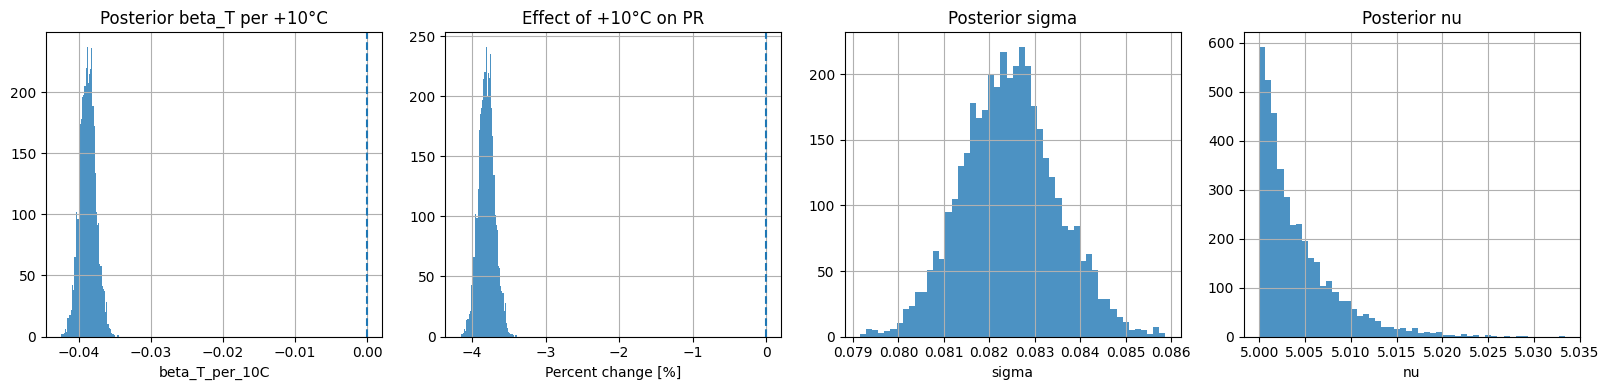

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
plots = [
    ("Posterior beta_T per +10°C", beta_T_per_10C, "beta_T_per_10C", True),
    ("Effect of +10°C on PR", effect_10C_pct, "Percent change [%]", True),
    ("Posterior sigma", sigma, "sigma", False),
    ("Posterior nu", nu, "nu", False),
]
for ax, (title, samples, xlabel, zero) in zip(axes, plots):
    ax.hist(samples, bins=50, alpha=0.8)
    if zero:
        ax.axvline(0, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(True)
plt.tight_layout()
plt.show()

## 8. Posterior predictive check

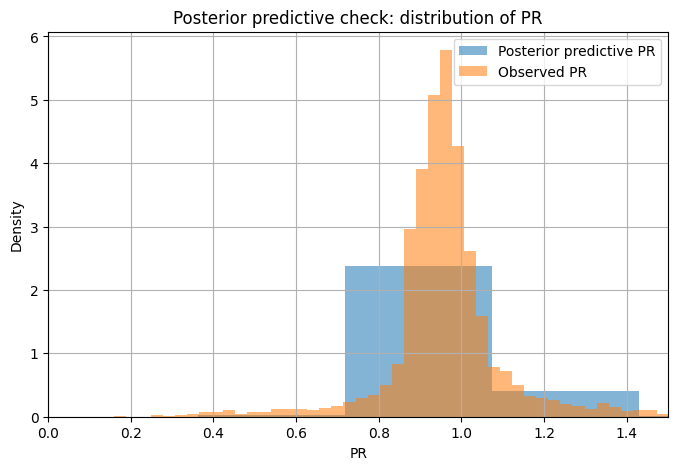

In [ ]:
PR_pred = fit.stan_variable("PR_pred")
y_pred = fit.stan_variable("y_pred")

plt.figure(figsize=(8, 5))
plt.hist(PR_pred.flatten(), bins=100, density=True, alpha=0.55, label="Posterior predictive PR")
plt.hist(df["PR"], bins=80, density=True, alpha=0.55, label="Observed PR")
plt.xlim(0.3, 2.0)
plt.xlabel("PR")
plt.ylabel("Density")
plt.title("Posterior predictive check: distribution of PR")
plt.xlim([0, 1.5])
plt.legend()
plt.show()

## 9. Residual diagnostics — motivation for Model 2

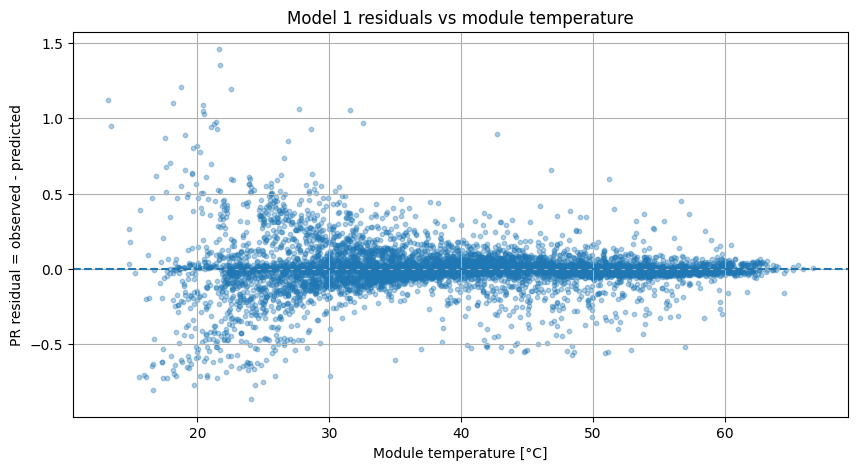

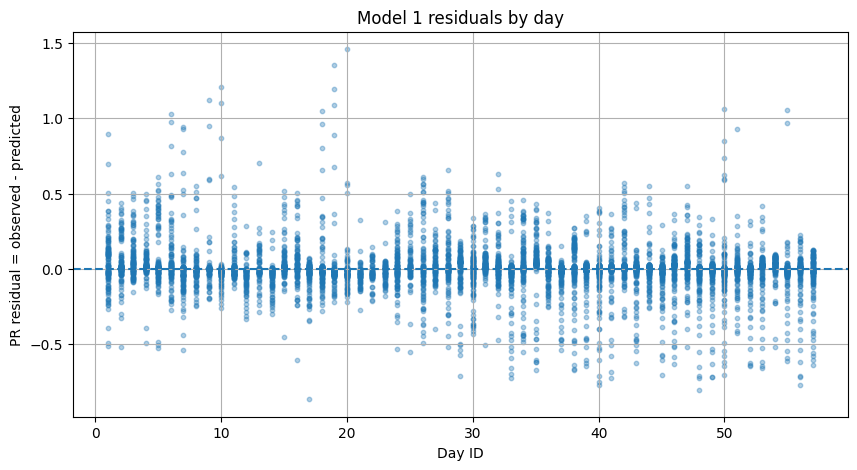

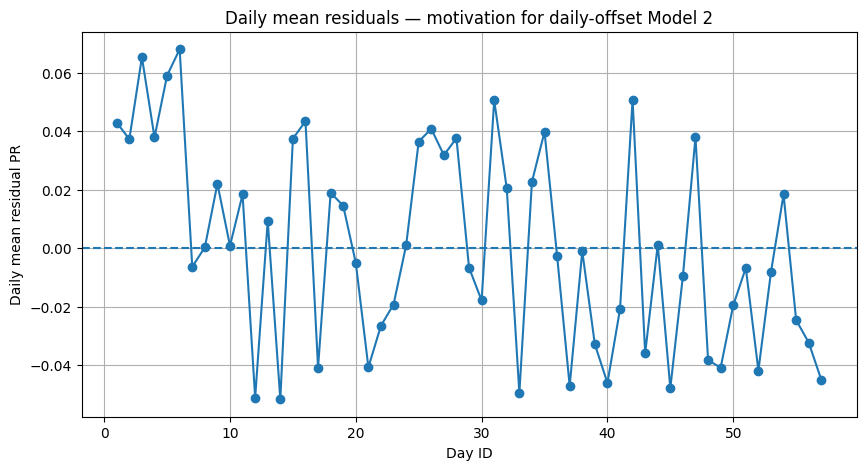

In [ ]:
PR_mu_mean = np.exp(mu).mean(axis=0)

df_check = df.copy()
df_check["PR_pred_mean"] = PR_mu_mean
df_check["residual_PR"] = df_check["PR"] - df_check["PR_pred_mean"]

plt.figure(figsize=(10, 5))
plt.scatter(df_check["T_module_C"], df_check["residual_PR"], s=10, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.xlabel("Module temperature [°C]")
plt.ylabel("PR residual = observed - predicted")
plt.title("Model 1 residuals vs module temperature")
plt.show()

if "day_id" in df_check.columns:
    plt.figure(figsize=(10, 5))
    plt.scatter(df_check["day_id"], df_check["residual_PR"], s=10, alpha=0.35)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Day ID")
    plt.ylabel("PR residual = observed - predicted")
    plt.title("Model 1 residuals by day")
    plt.show()

    daily_res = df_check.groupby("day_id").agg(daily_mean_residual=("residual_PR", "mean")).reset_index()
    plt.figure(figsize=(10, 5))
    plt.plot(daily_res["day_id"], daily_res["daily_mean_residual"], "o-")
    plt.axhline(0, linestyle="--")
    plt.xlabel("Day ID")
    plt.ylabel("Daily mean residual PR")
    plt.title("Daily mean residuals — motivation for daily-offset Model 2")
    plt.show()
else:
    print("No day_id column found, skipping daily residual diagnostics.")

## 10. Save ArviZ object

In [ ]:
idata1 = az.from_cmdstanpy(
    posterior=fit,
    posterior_predictive=["y_pred"],
    observed_data={"y": y},
    log_likelihood=["log_lik"],
)


with open("idata_model1_temperature_studentt.pkl", "wb") as f:
    pickle.dump(idata1, f)

print("Saved: idata_model1_temperature_studentt.pkl")

Saved: idata_model1_temperature_studentt.pkl


## Interpretation

Model 1 is a robust temperature-only baseline. Temperature is min-max normalized, so $x_T \in [0,1]$. In this scale, $\alpha$ is the expected $\log(PR)$ at the minimum observed module temperature and $\beta_T$ is the change in $\log(PR)$ between the minimum and maximum observed module temperature. The $+10^\circ C$ effect is included as a physical-scale summary. The Student-t likelihood makes the model less sensitive to remaining outliers. The model does not include wind or day-level effects.